In [2]:
%load_ext autoreload
%autoreload 2
import os, sys, pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.stats import pearsonr

from inDecay import PATH
os.chdir(PATH.main_dir)

celltype_rename = ['iPSC', 'CHO', 'mESC', 'HAP1', 'K562']
cell_palette = {
    'iPSC': '#677e98',
    'CHO':  '#a698a1',
    'mESC': '#ceac2d',
    'HAP1': '#c27c44',
    'K562': '#9c9376',
}
frame_labels = {0: 'In-frame (+0)', 1: '+1 Frameshift', 2: '+2 Frameshift'}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Per-Frame Breakdown (Phase 2)

In [ ]:
from inDecay import analysis_fn as inDecay_analysis_fn

# Paths to TestY and pretrained predictions (same as above, using local pretrained dir)
testY_path_dict = {
    "iPSC": f"{PATH.main_dir}/results/Testset_Y/iPSC_TestY.pkl",
    "CHO":  f"{PATH.main_dir}/results/Testset_Y/CHO_TestY.pkl",
    "mESC": f"{PATH.main_dir}/results/Testset_Y/mESC_TestY.pkl",
    "HAP1": f"{PATH.main_dir}/results/Testset_Y/HAP1_TestY.pkl",
    "K562": f"{PATH.main_dir}/results/Testset_Y/K562_TestY.pkl",
}

pred_path_dict = {
    "iPSC": f"{PATH.main_dir}/pretrained/iPSC_featv5_pretrainedTestPred.pkl",
    "CHO":  f"{PATH.main_dir}/pretrained/CHO_featv5_pretrainedTestPred.pkl",
    "mESC": f"{PATH.main_dir}/pretrained/mESC_featv5_pretrainedTestPred.pkl",
    "HAP1": f"{PATH.main_dir}/pretrained/HAP1_featv5_pretrainedTestPred.pkl",
    "K562": f"{PATH.main_dir}/pretrained/K562_featv5_pretrainedTestPred.pkl",
}

In [ ]:
def read_pkl(path):
    with open(path, 'rb') as f:
        Y = pkl.load(f)
    f.close()
    return Y

frame_rows = []
for cell in celltype_rename:
    Y_lookup  = read_pkl(testY_path_dict[cell])
    pred_lookup = read_pkl(pred_path_dict[cell])

    frame_res = inDecay_analysis_fn.assessment_recipe_frame_breakdown(Y_lookup, pred_lookup)

    row = {
        'celltype': cell,
        'frame0_r2': frame_res['frame0_r2'],   # in-frame (+0)
        'frame1_r2': frame_res['frame1_r2'],   # +1 frameshift
        'frame2_r2': frame_res['frame2_r2'],   # +2 frameshift
        # store per-oligo lists for scatter plots
        'frame0_y':    frame_res['frame0_y'],
        'frame0_pred': frame_res['frame0_pred'],
        'frame1_y':    frame_res['frame1_y'],
        'frame1_pred': frame_res['frame1_pred'],
        'frame2_y':    frame_res['frame2_y'],
        'frame2_pred': frame_res['frame2_pred'],
    }
    frame_rows.append(row)
    print(f"{cell}  frame0_r2={frame_res['frame0_r2']:.3f}  "
          f"frame1_r2={frame_res['frame1_r2']:.3f}  "
          f"frame2_r2={frame_res['frame2_r2']:.3f}")

frame_df = pd.DataFrame(frame_rows)

iPSC  frame0_r2=0.848  frame1_r2=0.819  frame2_r2=0.818
CHO  frame0_r2=0.803  frame1_r2=0.775  frame2_r2=0.763
mESC  frame0_r2=0.859  frame1_r2=0.832  frame2_r2=0.834
HAP1  frame0_r2=0.849  frame1_r2=0.834  frame2_r2=0.838
K562  frame0_r2=0.846  frame1_r2=0.823  frame2_r2=0.835


In [ ]:
import pickle as pkl
# Save summary R² CSV (for Figure 2 additional panels)
r2_summary = frame_df[['celltype','frame0_r2','frame1_r2','frame2_r2']].copy()
r2_summary.to_csv(f"{PATH.main_dir}/results/benchmarking/frame_breakdown_r2.csv", index=False)

# Save full per-oligo data as pkl (for supplementary scatter figure)
with open(f"{PATH.main_dir}/results/benchmarking/frame_breakdown_peroligo.pkl", 'wb') as f:
    pkl.dump(frame_df, f)

r2_summary

,celltype,frame0_r2,frame1_r2,frame2_r2
0,iPSC,0.848340,0.818686,0.817919
1,CHO,0.803359,0.775008,0.762761
2,mESC,0.859038,0.832431,0.833634
3,HAP1,0.849073,0.834135,0.838429
4,K562,0.845975,0.822867,0.834661


## Supplementary Figure — Per-Frame Prediction Accuracy 

**Layout:** 3 rows (in-frame +0, +1 fs, +2 fs) × 2 columns
- **Left column**: Scatter of observed vs predicted frame ratio per oligo, all 5 cell types overlaid in different colors. Pearson r² shown per cell type as legend.
- **Right column**: Bar chart of R² per cell type (inDecay only), same 3 frames.

In [4]:
# Load per-oligo frame breakdown data (produced by Benchmarking.ipynb)
with open(f"{PATH.main_dir}/results/benchmarking/frame_breakdown_peroligo.pkl", 'rb') as f:
    frame_df = pkl.load(f)

# Load R² summary
r2_df = pd.read_csv(f"{PATH.main_dir}/results/benchmarking/frame_breakdown_r2.csv")
r2_df

,celltype,frame0_r2,frame1_r2,frame2_r2
0,iPSC,0.848340,0.818686,0.817919
1,CHO,0.803359,0.775008,0.762761
2,mESC,0.859038,0.832431,0.833634
3,HAP1,0.849073,0.834135,0.838429
4,K562,0.845975,0.822867,0.834661


In [5]:
# Build long-form scatter dataframe for all cell types and frames
scatter_rows = []
for _, row in frame_df.iterrows():
    cell = row['celltype']
    for frame in [0, 1, 2]:
        y_vals    = row[f'frame{frame}_y']
        pred_vals = row[f'frame{frame}_pred']
        for y_val, p_val in zip(y_vals, pred_vals):
            scatter_rows.append({
                'celltype': cell,
                'frame': frame,
                'observed': y_val,
                'predicted': p_val,
            })
scatter_long = pd.DataFrame(scatter_rows)
scatter_long.head()

,celltype,frame,observed,predicted
0,iPSC,0,0.021579,0.052814
1,iPSC,0,0.229379,0.211394
2,iPSC,0,0.086229,0.181789
3,iPSC,0,0.014065,0.040953
4,iPSC,0,0.221020,0.279577


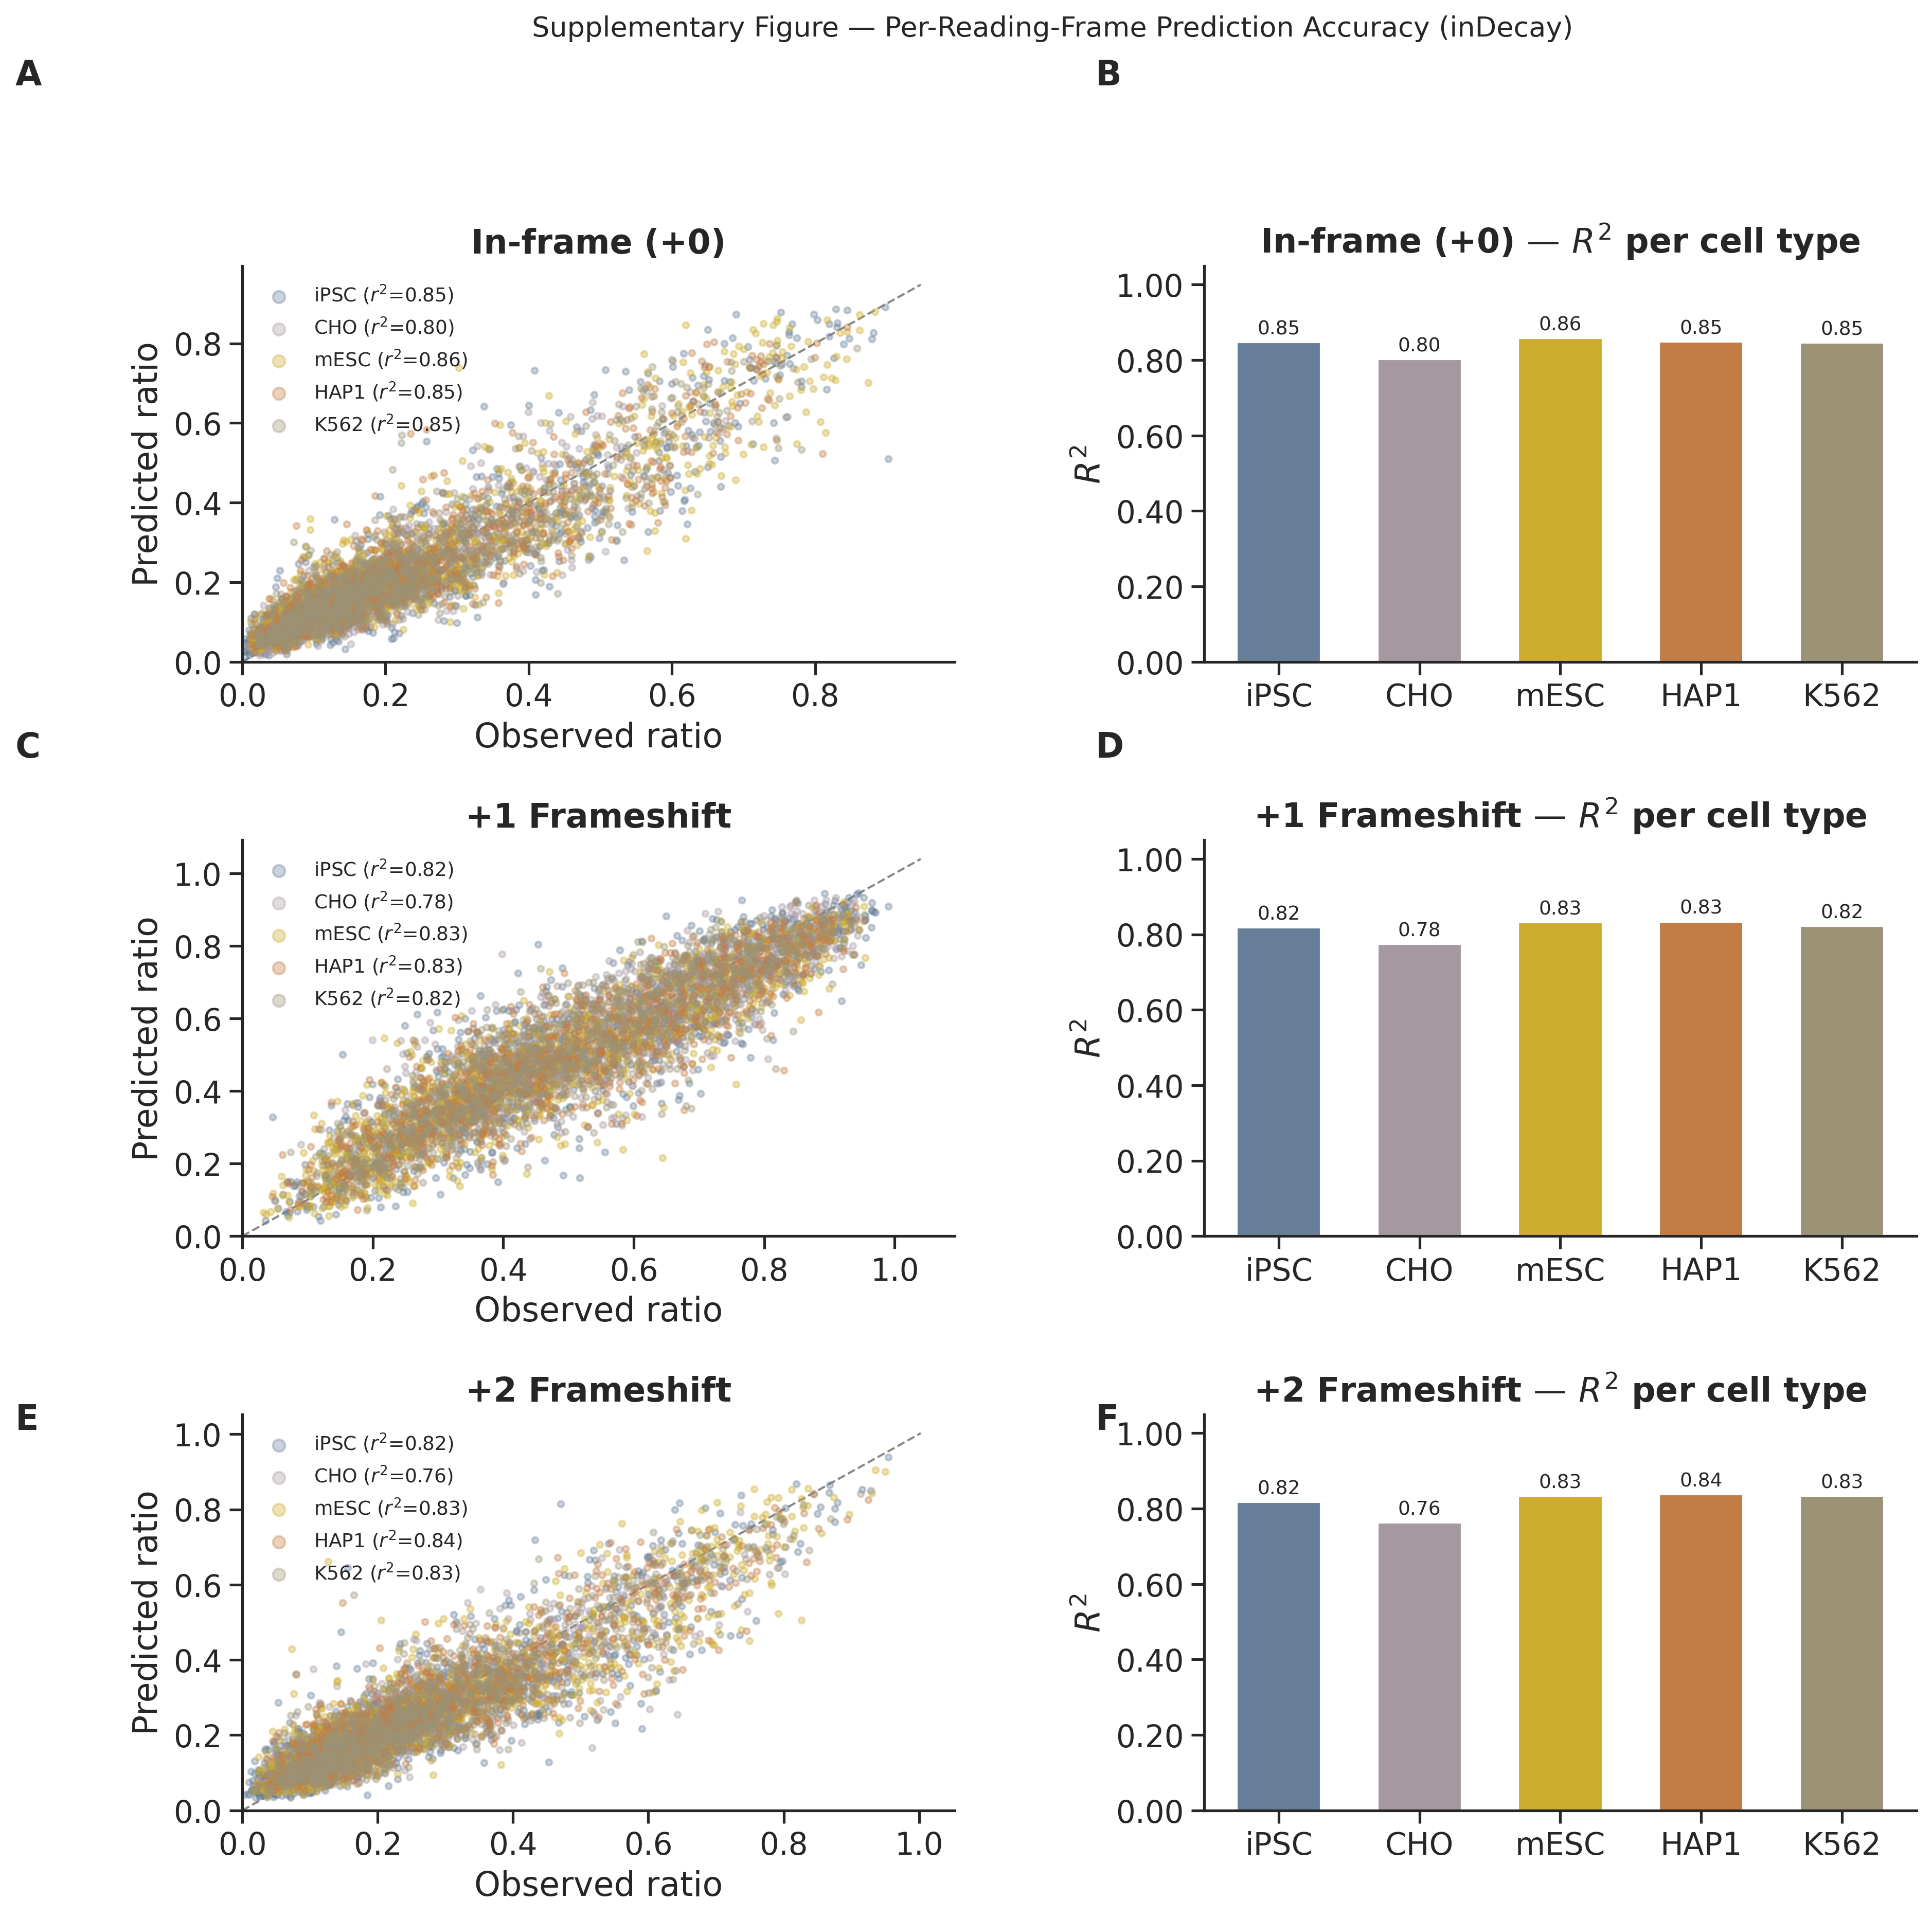

Saved: results/benchmarking/Supp_FrameBreakdown.pdf


In [6]:
sns.set_theme(style='ticks', font_scale=1.3)

fig = plt.figure(figsize=(14, 13), dpi=300, frameon=False)
gs = fig.add_gridspec(nrows=3, ncols=2, hspace=0.45, wspace=0.35)

for row_i, frame in enumerate([0, 1, 2]):
    # ── Left panel: scatter ────────────────────────────────────────────
    ax_scatter = fig.add_subplot(gs[row_i, 0])
    frame_data = scatter_long.query('frame == @frame')

    legend_handles = []
    for cell in celltype_rename:
        sub = frame_data.query('celltype == @cell')
        r2_val = r2_df.loc[r2_df['celltype'] == cell, f'frame{frame}_r2'].values[0]
        h = ax_scatter.scatter(
            sub['observed'], sub['predicted'],
            color=cell_palette[cell], alpha=0.35, s=8,
            label=f'{cell} ($r^2$={r2_val:.2f})',
            rasterized=True,
        )
        legend_handles.append(h)

    # diagonal reference line
    lim_max = max(frame_data['observed'].max(), frame_data['predicted'].max()) * 1.05
    ax_scatter.plot([0, lim_max], [0, lim_max], '--', color='#888888', lw=1, zorder=0)
    ax_scatter.set_xlim(left=0)
    ax_scatter.set_ylim(bottom=0)
    ax_scatter.set_xlabel('Observed ratio')
    ax_scatter.set_ylabel('Predicted ratio')
    ax_scatter.set_title(frame_labels[frame], fontweight='bold', pad=6)
    ax_scatter.legend(
        handles=legend_handles,
        fontsize=9, frameon=False,
        loc='upper left', markerscale=2,
    )
    sns.despine(ax=ax_scatter)

    # ── Right panel: R² bar chart ──────────────────────────────────────
    ax_bar = fig.add_subplot(gs[row_i, 1])
    r2_vals = [r2_df.loc[r2_df['celltype'] == cell, f'frame{frame}_r2'].values[0]
               for cell in celltype_rename]
    colors  = [cell_palette[c] for c in celltype_rename]

    bars = ax_bar.bar(celltype_rename, r2_vals, color=colors, edgecolor='white', width=0.6)
    ax_bar.set_ylim(0, 1.05)
    ax_bar.set_ylabel(r'$R^2$')
    ax_bar.set_title(f'{frame_labels[frame]} — $R^2$ per cell type', fontweight='bold', pad=6)
    ax_bar.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

    # annotate bar values
    for bar, val in zip(bars, r2_vals):
        ax_bar.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.01,
            f'{val:.2f}',
            ha='center', va='bottom', fontsize=9,
        )
    sns.despine(ax=ax_bar)

# panel labels
for col_i, letter in enumerate(['A', 'B', 'C', 'D', 'E', 'F']):
    row_i = col_i // 2
    col_j = col_i % 2
    x_pos = 0.02 + col_j * 0.50
    y_pos = 0.97 - row_i * 0.335
    fig.text(x_pos, y_pos, letter, fontsize=16, fontweight='bold')

fig.suptitle(
    'Supplementary Figure — Per-Reading-Frame Prediction Accuracy (inDecay)',
    fontsize=13, y=1.005,
)

plt.savefig(
    f"{PATH.main_dir}/results/benchmarking/Supp_FrameBreakdown.pdf",
    format='pdf', bbox_inches='tight',
)
plt.show()
print("Saved: results/benchmarking/Supp_FrameBreakdown.pdf")